# Higher-Ordered ODE

In this notebook, we consider a second-ordered ODE:

\begin{equation*}
x^{(2)}(t) = \sin(2t) − x^{(0)}(t), \qquad \xx_0 = (-1, 0, 1),
\end{equation*}

where the solution $x(t)$ is sought on the interval $t \in [0, 10]$.  In this case, the ODE has an analytic solution,

\begin{equation*}
x(t) = \tfrac 1 3 \big(2\sin(t) - 3\cos(t) - \sin(2t)\big).
\end{equation*}

In [1]:
import numpy as np
from math import cos, sin
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

from rodeo.ibm import ibm_init
from rodeo.ode import *
from jax.config import config
config.update("jax_enable_x64", True)

The setup is almost identical to that of the example in the Introduction to **RODEO** notebook. The major difference is to set `n_deriv_prior=4`$(p=4)$ in this example since we are considering $q=2$ order instead of $q=1$ order ODE.

In [23]:
# RHS of ODE
def ode_fun(X_t, t, theta=None):
    return jnp.array([[jnp.sin(2*t) -X_t[0, 0]]])

# problem setup and intialization
n_deriv = 2  # Total state; q
n_obs = 1  # Total observations
n_deriv_prior = 4 # p

# Time interval on which a solution is sought.
n_eval = 100
tmin = 0.
tmax = 10.

# The rest of the parameters can be tuned according to ODE
# For this problem, we will use
sigma = .01
sigma = jnp.array([sigma]*n_obs)

# Initial W for jax block
W_block = jnp.array([[[0, 0, 1, 0]]])

# Initial x0 for jax block
x0_block = jnp.array([[-1., 0., 1., 0.]])

# Get parameters needed to run the solver
dt = (tmax-tmin)/n_eval  # step size
n_order = jnp.array([n_deriv_prior]*n_obs)
ode_init = ibm_init(dt, n_order, sigma)

# Jit solver
key = jax.random.PRNGKey(0)
sim_jit = jax.jit(solve_sim, static_argnums=(1, 6))
xt = sim_jit(key=key, fun=ode_fun,
        x0=x0_block, theta=None,
        tmin=tmin, tmax=tmax, n_eval=n_eval,
        wgt_meas=W_block, **ode_init)

To see how well this approximation does against the exact solution, we can graph them together. First, we will define the functions of the exact solution for this example.

In [24]:
# Exact Solution for x_t^{(0)}
def ode_exact_x(t):
    return (-3*cos(t) + 2*sin(t) - sin(2*t))/3

# Exact Solution for x_t^{(1)}
def ode_exact_x1(t):
    return (-2*cos(2*t) + 3*sin(t) + 2*cos(t))/3

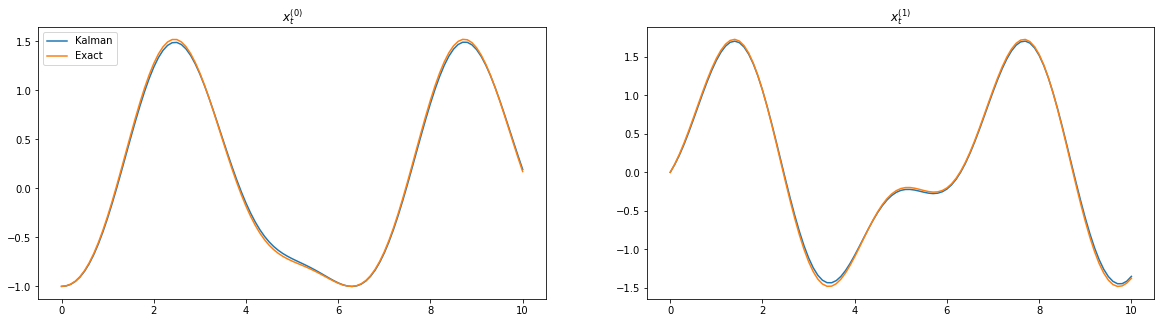

In [25]:
# Get exact solutions for x^{(0)}, x^{(1)}
tseq = np.linspace(tmin, tmax, n_eval+1)
exact_x = np.zeros(n_eval+1)
exact_x1 = np.zeros(n_eval+1)
for t in range(n_eval+1):
    exact_x[t] = ode_exact_x(tseq[t])
    exact_x1[t] = ode_exact_x1(tseq[t])

# Plot them
fig, axs = plt.subplots(1, 2, figsize=(20, 5))
axs[0].plot(tseq, xt[:,0,0], label = 'rodeo')
axs[0].plot(tseq, exact_x, label = 'Exact')
axs[0].set_title("$x^{(0)}_t$")
axs[0].legend(loc='upper left')
axs[1].plot(tseq, xt[:,0,1], label = 'rodeo')
axs[1].plot(tseq, exact_x1, label = 'Exact')
axs[1].set_title("$x^{(1)}_t$")
plt.show()